In [ ]:
# Importing the os module for directory operations
#import os

# Importing isfile and join functions from os.path to check file status and create file paths
#from os.path import isfile, join

# Import time for delays
#import time



# Import tqdm for creating progress bars
#from tqdm import tqdm # type: ignore

# Importing pandas for data manipulation and analysis
#import pandas as pd # type: ignore

# Importing librosa for audio processing
#import librosa # type: ignore

# Importing pyplot from matplotlib for plotting
#import matplotlib.pyplot as plt # type: ignore

# Importing numpy for numerical operations
#import numpy as np # type: ignore

# Importing train_test_split for splitting datasets
#from sklearn.model_selection import train_test_split # type: ignore

# Importing timer to measure time intervals
#from timeit import default_timer as timer

# Importing the wave module to handle .wav audio files
#import wave
# Import tabulate for generating tables in text format
#from tabulate import tabulate # type: ignore

'''
============================== Evaluation ============================== 
'''

# Importing classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve for model evaluation
#from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve # type: ignore
# Importing seaborn for statistical data visualization
#import seaborn as sn # type: ignore

# Import cycle from itertools for cycling through colors
#from itertools import cycle

'''
============================== TENSORFLOW ============================== 
'''

# Importing Sequential and Model from tensorflow.keras for building neural networks
#from tensorflow.keras.models import Sequential, Model # type: ignore

# Importing regularizers and optimizers from tensorflow.keras for regularization and optimization
#from tensorflow.keras import regularizers, optimizers # type: ignore

# Importing various neural network layers from tensorflow.keras
#from tensorflow.keras.layers import Dense, Conv1D, Flatten, Activation, MaxPooling1D, Dropout # type: ignore

# Importing plot_model for model visualization and to_categorical for one-hot encoding
#from tensorflow.keras.utils import plot_model, to_categorical # type: ignore

# Import the Adam optimizer from tensorflow.keras
#from tensorflow.keras.optimizers import Adam # type: ignore

# ============================== BASIC LIBRARIES ==============================
import sys
import os
import time
import random
import warnings
warnings.filterwarnings("ignore")

from os.path import isfile, join
from timeit import default_timer as timer
from itertools import cycle

# Progress bar
from tqdm import tqdm

# ============================== DATA HANDLING ==============================

#import numpy as np
import pandas as pd
import numpy as np
# ============================== AUDIO PROCESSING ==============================

import librosa
import librosa.display

# ============================== VISUALIZATION ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# Professional plot style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("viridis")

# ============================== SKLEARN ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)

# ============================== TENSORFLOW / KERAS ==============================

import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense,
    Conv1D,
    Flatten,
    Activation,
    MaxPooling1D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers

# ============================== REPRODUCIBILITY ==============================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


## Parsing the Dataset
A `Diagnosis` class is defined with an initializer to store patient information:

- **patient_id**: ID of the patient.
- **diagnosis**: Diagnosis of the patient.
- **audio_file_path**: The file path of the patient's audio file.


In [ ]:

# ============================== DIAGNOSIS DATA CLASS ==============================

class Diagnosis:
    def __init__(self, patient_id, diagnosis, audio_file_path):
        self.patient_id = patient_id
        self.diagnosis = diagnosis
        self.audio_file_path = audio_file_path
        
        # These will be filled later during processing
        self.features = None
        self.encoded_label = None
        self.predicted_label = None
        self.predicted_probabilities = None

    def __repr__(self):
        return (f"Diagnosis(patient_id={self.patient_id}, "
                f"diagnosis={self.diagnosis}, "
                f"path={os.path.basename(self.audio_file_path)})")



### Paths
Dynamic paths are defined for accessing files:

- **`PATH`**: Directory path to audio and text files.
- **`diagnosis_file`**: Path to the patient diagnosis CSV file.


In [ ]:


# ============================== DATA PATH CONFIGURATION ==============================

# You can change this base path if needed
BASE_DATA_PATH = r"YOUR_DATABASE_PATH"        #****local path of the database**"""

AUDIO_DIR = os.path.join(BASE_DATA_PATH, "audio_and_txt_files")
DIAGNOSIS_FILE = os.path.join(BASE_DATA_PATH, "patient_diagnosis.csv")

# Quick verification
print("Audio Directory Exists:", os.path.exists(AUDIO_DIR))
print("Diagnosis File Exists:", os.path.exists(DIAGNOSIS_FILE))

Audio Directory Exists: True
Diagnosis File Exists: True


In [ ]:
# Function to get a list of .wav files in the audio directory
# ============================== LOAD AUDIO FILES ==============================
def get_wav_files(audio_dir):
    """
    Returns a sorted list of full paths to valid .wav files.
    Ensures:
    - Directory exists
    - Case-insensitive extension handling
    - No empty/corrupted files
    """
    
    if not os.path.isdir(audio_dir):
        raise ValueError(f"Directory does not exist: {audio_dir}")
    
    wav_files = []
    
    for file in os.listdir(audio_dir):
        full_path = os.path.join(audio_dir, file)
        
        # Check if file and .wav (case-insensitive)
        if os.path.isfile(full_path) and file.lower().endswith(".wav"):
            
            # Check file is not empty
            if os.path.getsize(full_path) > 0:
                wav_files.append(full_path)
    
    if len(wav_files) == 0:
        raise FileNotFoundError("No valid .wav files found.")
    
    wav_files = sorted(wav_files)
    
    print(f"Total WAV files loaded: {len(wav_files)}")
    
    return wav_files

### Loading and Mapping Diagnosis Data to Audio Files

`load_diagnosis_data(PATH, diagnosis_file)`:
- Checks if the diagnosis file exists, raises an error if not.
- Reads the diagnosis file into a DataFrame, handling possible read errors.
- Retrieves the list of `.wav` files and the audio path.
- Creates a dictionary mapping patient IDs to diagnoses.
- Iterates over `.wav` files, extracting patient IDs and associating diagnoses.
- Creates `Diagnosis` objects for each `.wav` file, appending them to a list.
- Returns the list of `Diagnosis` objects.

In [ ]:
# ============================== LOAD DIAGNOSIS DATA ==============================

def load_diagnosis_data(audio_dir, diagnosis_file):
    """
    Loads diagnosis CSV and maps each audio file to its correct label.
    Ensures:
    - Correct patient ID extraction
    - Proper label mapping
    - No corrupted entries
    - Class distribution visibility
    """

    # ---------- Check CSV ----------
    if not os.path.isfile(diagnosis_file):
        raise ValueError(f"Diagnosis file not found: {diagnosis_file}")

    diagnosis_df = pd.read_csv(diagnosis_file)

    if diagnosis_df.empty:
        raise ValueError("Diagnosis CSV is empty.")

    # Ensure correct column names (ICBHI standard format)
    diagnosis_df.columns = ["patient_id", "diagnosis"]

    # Create fast lookup dictionary
    diagnosis_dict = dict(zip(diagnosis_df["patient_id"], diagnosis_df["diagnosis"]))

    # ---------- Load Audio Files ----------
    wav_files = get_wav_files(audio_dir)

    diagnosis_list = []

    for idx, full_path in enumerate(wav_files):

        file_name = os.path.basename(full_path)

        try:
            # ICBHI format: first 3 digits = patient ID
            patient_id = int(file_name.split("_")[0])

            if patient_id in diagnosis_dict:
                diagnosis = diagnosis_dict[patient_id]

                diagnosis_obj = Diagnosis(
                    patient_id=patient_id,
                    diagnosis=diagnosis,
                    audio_file_path=full_path
                )

                diagnosis_list.append(diagnosis_obj)

        except Exception as e:
            print(f"Skipping file {file_name}: {e}")

    # ---------- Check Class Distribution ----------
    labels = [d.diagnosis for d in diagnosis_list]
    class_counts = pd.Series(labels).value_counts()

    print("\nClass Distribution:")
    print(class_counts)

    print(f"\nTotal usable samples: {len(diagnosis_list)}")

    return diagnosis_list

### Comprehensive Analysis of Disease Distribution in Audio Files

The following code processes audio files and their corresponding diagnoses, generating various visualizations and statistics:

- **Constants Section**:
  - Lists audio files in the directory and extracts patient IDs.
  - Reads the patient diagnosis file and extracts labels for the audio files.
  - Computes and prints class counts.

- **Table of Classes**:
  - Converts class counts to a table and prints it.

- **Info Section**:
  - Calculates and prints the total number of classes and patients.

- **Bar Chart**:
  - Plots a bar chart showing the count of diseases in the sound files.

- **Pie Chart of Class Distribution**:
  - Plots a pie chart showing the distribution of classes in the sound files.

- **Histogram of Audio File Duration**:
  - Analyzes and plots a histogram of the durations of the audio files, including the mean duration.

- **Box Plot of Audio File Duration**:
  - Creates a box plot of the audio file durations, with annotations for outliers.

- **Statistical Summary of Audio File Durations**:
  - Computes and prints a statistical summary of the audio file durations.


Analyzing Dataset...

Total WAV files loaded: 920

Class Distribution:
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

Total usable samples: 918

Class Distribution:

COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

Total Number of Classes: 8
Total Number of Audio Samples: 918
Imbalance Ratio (Max/Min): 793.00


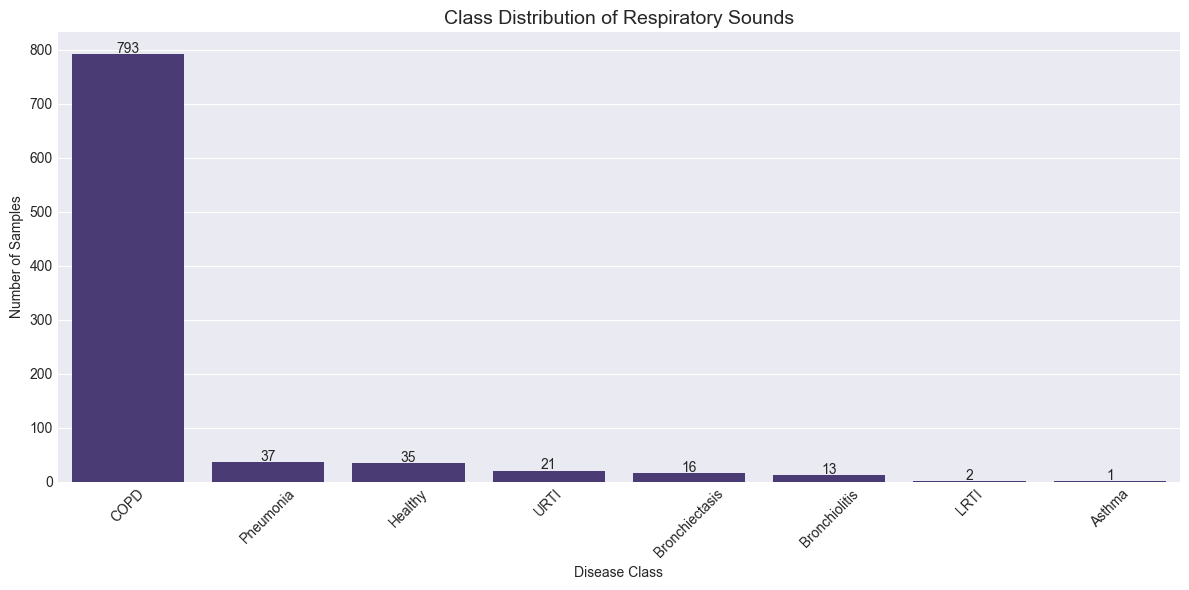

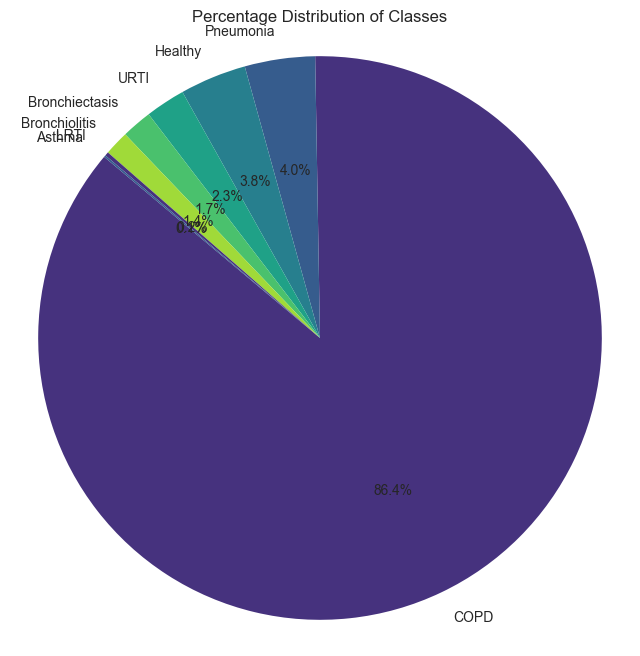


Mean Audio Duration: 21.50 seconds


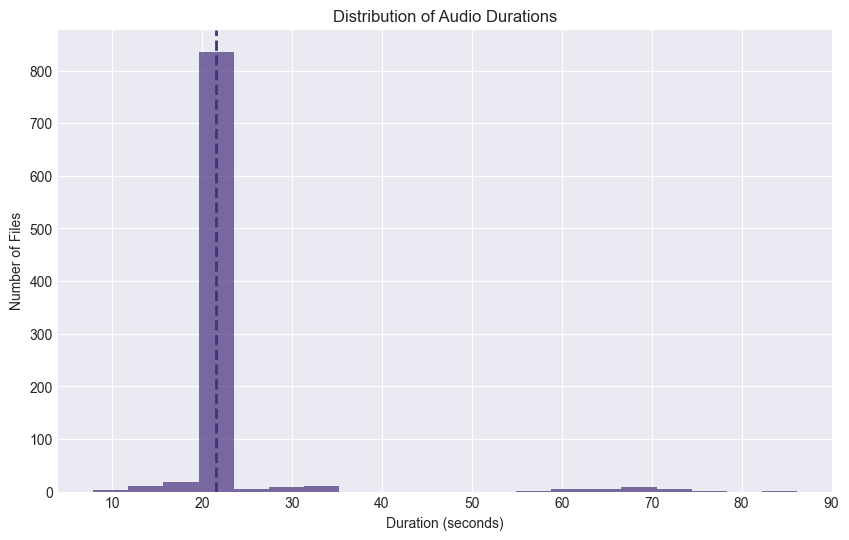

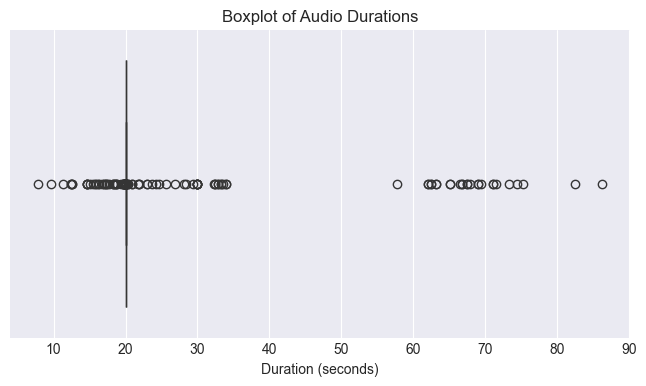


Audio Duration Statistics:
count    918.00
mean      21.50
std        8.32
min        7.86
25%       20.00
50%       20.00
75%       20.00
max       86.20
dtype: float64


In [ ]:
# ============================== DATASET ANALYSIS & VISUALIZATION ==============================
import numpy as np
try:
    print("\nAnalyzing Dataset...\n")

    # ---------- Load Diagnosis Data Properly ----------
    diagnosis_list = load_diagnosis_data(AUDIO_DIR, DIAGNOSIS_FILE)

    # Extract labels
    labels = np.array([d.diagnosis for d in diagnosis_list])

    # ---------- Class Distribution ----------
    class_counts = pd.Series(labels).value_counts()

    print("\nClass Distribution:\n")
    print(class_counts)

    total_classes = len(class_counts)
    total_samples = len(labels)

    print(f"\nTotal Number of Classes: {total_classes}")
    print(f"Total Number of Audio Samples: {total_samples}")

    # ---------- Imbalance Ratio ----------
    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

    # ============================== BAR PLOT ==============================

    plt.figure(figsize=(12, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values)

    plt.title("Class Distribution of Respiratory Sounds", fontsize=14)
    plt.xlabel("Disease Class")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45)

    for i, v in enumerate(class_counts.values):
        plt.text(i, v + 2, str(v), ha='center')

    plt.tight_layout()
    plt.show()

    # ============================== PIE CHART ==============================

    plt.figure(figsize=(8, 8))
    plt.pie(
        class_counts.values,
        labels=class_counts.index,
        autopct='%1.1f%%',
        startangle=140
    )
    plt.title("Percentage Distribution of Classes")
    plt.axis("equal")
    plt.show()

    # ============================== AUDIO DURATION ANALYSIS ==============================

    durations = []

    for d in diagnosis_list:
        try:
            audio, sr = librosa.load(d.audio_file_path, sr=None)
            duration = librosa.get_duration(y=audio, sr=sr)
            durations.append(duration)
        except Exception as e:
            print(f"Skipping file due to error: {e}")

    durations = np.array(durations)

    mean_duration = np.mean(durations)

    print(f"\nMean Audio Duration: {mean_duration:.2f} seconds")

    # ============================== HISTOGRAM ==============================

    plt.figure(figsize=(10, 6))
    plt.hist(durations, bins=20, alpha=0.7)
    plt.axvline(mean_duration, linestyle='dashed', linewidth=2)
    plt.title("Distribution of Audio Durations")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Number of Files")
    plt.show()

    # ============================== BOX PLOT ==============================

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=durations)
    plt.title("Boxplot of Audio Durations")
    plt.xlabel("Duration (seconds)")
    plt.show()

    # ============================== STATISTICAL SUMMARY ==============================

    duration_series = pd.Series(durations)
    print("\nAudio Duration Statistics:")
    print(duration_series.describe().round(2))

except Exception as e:
    print("ERROR during dataset analysis:")
    print(e)


Analyzing Dataset (After Class Modification)...

Total WAV files loaded: 920

Class Distribution:
COPD              793
Pneumonia          37
Healthy            35
URTI               21
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

Total usable samples: 918

Updated Class Distribution (Audio-Level):

COPD                 793
Pneumonia             37
Healthy               35
Bronchial_Disease     29
URTI                  21
Name: count, dtype: int64

Total Number of Classes: 5
Total Number of Audio Samples: 915
New Imbalance Ratio (Max/Min): 37.76


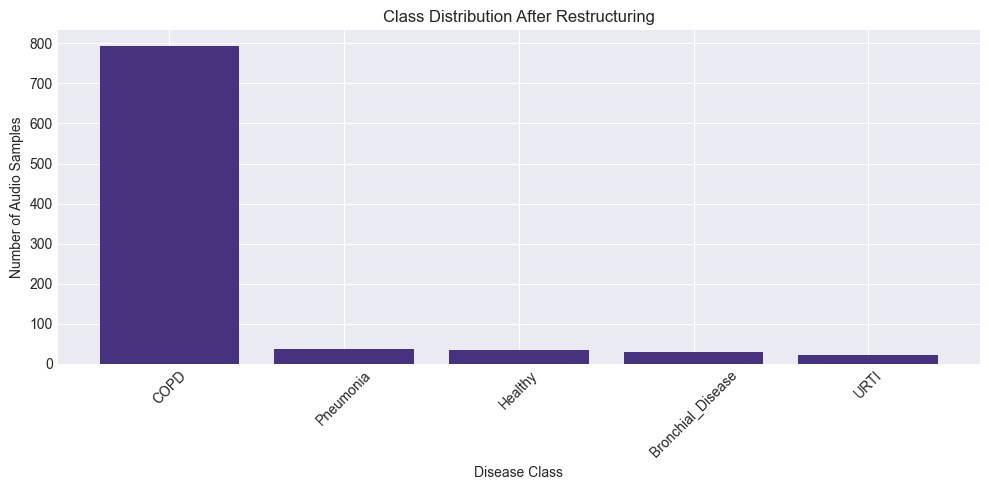

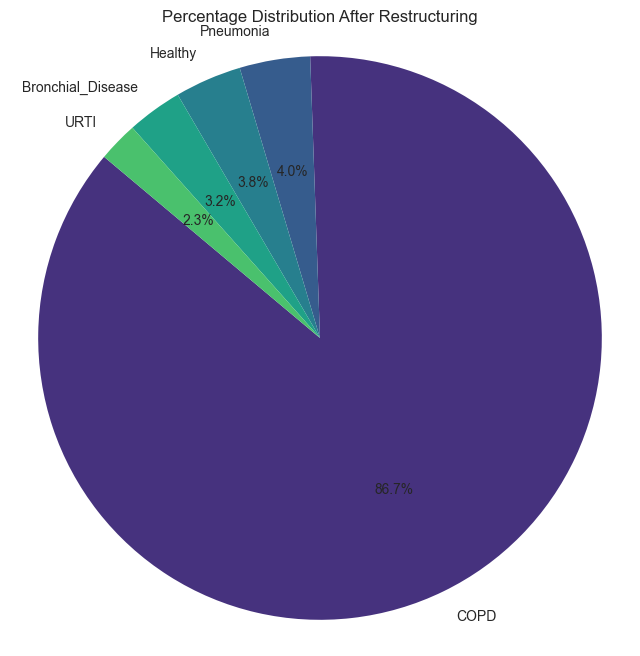

In [ ]:
# ============================== ****AUDIO-LEVEL RESTRUCTURING + ANALYSIS****** ==============================
try:
    print("\nAnalyzing Dataset (After Class Modification)...\n")

    # ---------- Load Diagnosis Data ----------
    diagnosis_list = load_diagnosis_data(AUDIO_DIR, DIAGNOSIS_FILE)

    # =========================================================
    # 1️⃣ REMOVE MINORITY SAMPLES - LRTI & ASTHMA (AUDIO LEVEL)
    # =========================================================
    diagnosis_list = [
        d for d in diagnosis_list
        if d.diagnosis not in ['LRTI', 'Asthma']
    ]

    # =========================================================
    # 2️⃣ MERGE Bronchiectasis + Bronchiolitis
    # =========================================================
    for d in diagnosis_list:
        if d.diagnosis in ['Bronchiectasis', 'Bronchiolitis']:
            d.diagnosis = 'Bronchial_Disease'

    # =========================================================
    # 3️⃣ Recalculate Labels
    # =========================================================
    labels = np.array([d.diagnosis for d in diagnosis_list])
    class_counts = pd.Series(labels).value_counts().sort_values(ascending=False)

    print("\nUpdated Class Distribution (Audio-Level):\n")
    print(class_counts)

    total_classes = len(class_counts)
    total_samples = len(labels)

    print(f"\nTotal Number of Classes: {total_classes}")
    print(f"Total Number of Audio Samples: {total_samples}")

    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"New Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

    # ============================== BAR PLOT ==============================

    plt.figure(figsize=(10, 5))
    plt.bar(class_counts.index, class_counts.values)
    plt.title("Class Distribution After Restructuring")
    plt.xlabel("Disease Class")
    plt.ylabel("Number of Audio Samples")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ============================== PIE CHART ==============================

    plt.figure(figsize=(8, 8))
    plt.pie(
        class_counts.values,
        labels=class_counts.index,
        autopct='%1.1f%%',
        startangle=140
    )
    plt.title("Percentage Distribution After Restructuring")
    plt.axis("equal")
    plt.show()

except Exception as e:
    print("ERROR during dataset analysis:")
    print(e)

## Feature Extraction

`audio_features(filename)`:
  - Loads the audio file and retrieves the sample rate.
  - Computes the Short-Time Fourier Transform (STFT) of the audio.
  - Extracts various audio features, including:
    - Mean Mel-frequency cepstral coefficients (MFCC).
    - Mean chromagram from STFT.
    - Mean mel-scaled spectrogram.
    - Mean spectral contrast.
    - Mean tonal centroid features (tonnetz).
  - Concatenates all features into a single feature vector.

In [ ]:
def audio_features(filename):
    try:
        # Load the audio file and get the sample rate
        sound, sample_rate = librosa.load(filename)
        # Compute the Short-Time Fourier Transform (STFT) of the sound
        stft = np.abs(librosa.stft(sound))

        # Compute the mean Mel-frequency cepstral coefficients (MFCC) over time
        mfccs = np.mean(librosa.feature.mfcc(y=sound, sr=sample_rate, n_mfcc=40), axis=1)
        # Compute the mean chromagram from STFT
        chroma = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate), axis=1)
        # Compute the mean mel-scaled spectrogram
        mel = np.mean(librosa.feature.melspectrogram(y=sound, sr=sample_rate), axis=1)
        # Compute the mean spectral contrast
        contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate), axis=1)
        # Compute the mean tonal centroid features (tonnetz)
        tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(sound), sr=sample_rate), axis=1)

        # Concatenate all the features into a single feature vector
        return np.concatenate((mfccs, chroma, mel, contrast, tonnetz))
    except Exception as e:
        raise RuntimeError(f"Error extracting audio features from file {filename}: {e}")

`data_points(PATH, diagnosis_file)`:
  - Initializes lists to store labels and features.
  - Maps diagnoses to numerical labels.
  - Loads diagnosis data.
  - Iterates over each diagnosis entry:
    - Appends the numerical label for the diagnosis to the labels list.
    - Extracts audio features and appends them to the features list.
  - Prints a completion message indicating the number of files processed.
  - Returns the labels and features as numpy arrays.

In [ ]:
def data_points(PATH, diagnosis_file):
    labels = []
    features = []

    #  NEW mapping (5 classes only)
    diagnosis_mapping = {
        "COPD": 0,
        "Healthy": 1,
        "URTI": 2,
        "Pneumonia": 3,
        "Bronchial_Disease": 4
    }

    try:
        diagnoses = load_diagnosis_data(PATH, diagnosis_file)  #actaully this will print the dataset so dont confuse...whwnever we use this function it show original distribution
    except (ValueError, FileNotFoundError, RuntimeError) as e:
        print(f"Error loading diagnosis data: {e}")
        return np.array([]), np.array([])

    # =====================================================
    # APPLY RESTRUCTURING HERE
    # =====================================================

    # Remove LRTI and Asthma
    diagnoses = [
        d for d in diagnoses
        if d.diagnosis not in ["LRTI", "Asthma"]
    ]

    # Merge Bronchiectasis & Bronchiolitis
    for d in diagnoses:
        if d.diagnosis in ["Bronchiectasis", "Bronchiolitis"]:
            d.diagnosis = "Bronchial_Disease"

    # =====================================================
    # Feature Extraction
    # =====================================================

    for diagnosis in tqdm(diagnoses, desc="Extracting Features", unit="file"):
        try:    
            features.append(audio_features(diagnosis.audio_file_path))
            labels.append(diagnosis_mapping[diagnosis.diagnosis])
        except Exception as e:
            tqdm.write(
                f"\033[1;91mWARNING:\033[0m Issue extracting features from: "
                f"{diagnosis.audio_file_path}. Error: {e}"
            )

    print(f'\n\033[1;92mFinished feature extraction from {len(features)} files\033[0m')

    return np.array(labels), np.array(features)

## Preprocessing

`preprocessing(labels, images)`:
  - Removes entries with labels for Asthma (6) and LRTI (7).
  - Splits data into training and testing sets.
  - One-hot encodes the labels.
  - Reshapes the data for model input.
  - Returns the preprocessed training and testing sets.

Additional steps:

- `Start timer`: Measures the preprocessing time.
- `Load data points`: Calls the `data_points` function to retrieve labels and features.
- `Preprocess data`: Calls the `preprocessing` function to prepare the data.
- `Calculate and print elapsed time`: Displays the time taken for preprocessing in minutes and seconds.
<br><br>
<p style="color:#ff3232; font-size:1.2em; font-weight:bold;">⚠️ Warning: Estimated Time of Completion (ETC): 22-25 minutes on a MacBook Air M2</p>

In [ ]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from timeit import default_timer as timer
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def preprocessing(labels, images):

    # Stratified split (VERY IMPORTANT: SMOTE only on train)
    X_train, X_test, y_train, y_test = train_test_split(
        images,
        labels,
        test_size=0.2,
        random_state=10,
        stratify=labels
    )

    print("Before SMOTE:", np.bincount(y_train))


     # =========================
    # 1. ApplyMild SMOTE
    # =========================
    # Instead of full balancing → reduce imbalance partially
    unique, counts = np.unique(y_train, return_counts=True)
    max_count = int(max(counts) * 0.5)   # only 70% of majority class

    sampling_strategy = {
        cls: max_count if count < max_count else count
        for cls, count in zip(unique, counts)
    }

    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42,
        k_neighbors=3   # safer for small classes
    )

    X_train, y_train = smote.fit_resample(X_train, y_train)

    print("After SMOTE:", np.bincount(y_train))

    # =========================
    # 2. Class Weights (after SMOTE)
    # =========================
    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights_array))

    print("Class Weights:", class_weights)

    # =========================
    # 5. One-hot encoding
    # =========================
    num_classes = len(np.unique(labels))

    y_train = to_categorical(y_train, num_classes=num_classes)
    y_test = to_categorical(y_test, num_classes=num_classes)

    return X_train, X_test, y_train, y_test, class_weights
    


start = timer()
# Load data
labels, images = data_points(AUDIO_DIR, DIAGNOSIS_FILE)  # ******images means features*****#
print("Labels shape:", len(labels))
print("Images shape:", len(images))

# Preprocess (Common)
X_train, X_test, y_train, y_test, class_weights = preprocessing(labels, images)

end = timer()
elapsed_time = end - start

minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print(f"Time taken: {minutes}:{seconds:02d} minutes ({elapsed_time:.0f} seconds)")

In [ ]:
# Verifying the results(class lables removed and two labels mergerd, total lables five)
# verifying the default or current shape of the data using which we reshape according to the models reqirement

print(np.unique(labels))
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


[0 1 2 3 4]
{np.int64(0): np.int64(793), np.int64(1): np.int64(35), np.int64(2): np.int64(21), np.int64(3): np.int64(37), np.int64(4): np.int64(29)}
X_train shape: (2406, 193)
y_train shape: (2406, 5)


### Selecting a Random .wav File and Displaying its Mel-Spectrogram

`select_random_wav_file(PATH)`:
  - Lists all `.wav` files in the specified directory.
  - Randomly selects one `.wav` file.
  - Returns the full path of the selected file and its name.

`display_mel_spectrogram(file_path, file_name)`:
  - Loads the audio file at the given path.
  - Splices the first 5 seconds of the audio.
  - Computes the mel-spectrogram of the spliced audio.
  - Displays the mel-spectrogram with a color bar and appropriate labels.

Additional steps:

- `Select a random .wav file`: Calls the `select_random_wav_file` function to choose a file from the specified directory.
- `Display mel-spectrogram`: Calls the `display_mel_spectrogram` function to visualize the spectrogram of the selected audio file.
- `Load necessary libraries`: Imports `os`, `numpy`, `librosa`, and `matplotlib` libraries required for file handling, random selection, audio processing, and plotting.

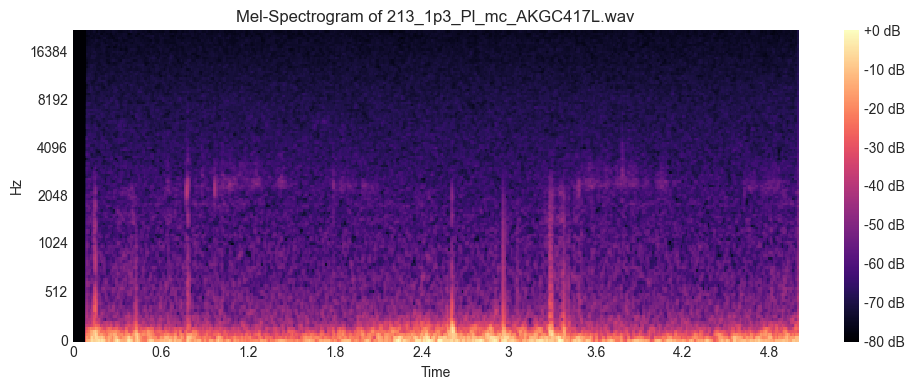

In [ ]:
# Function to randomly select a .wav file from a directory
def select_random_wav_file(PATH):
    files = [f for f in os.listdir(PATH) if f.endswith('.wav')]
    random_index = np.random.randint(0, len(files))
    selected_file = files[random_index]
    return os.path.join(PATH, selected_file), selected_file

# Function to display mel-spectrogram of the spliced audio file
def display_mel_spectrogram(file_path, file_name):
    # Load audio file
    y, sr = librosa.load(file_path, sr=None)  # Set sr=None to load the native sampling rate

    # Splice audio (example: first 5 seconds)
    duration = 5  # seconds
    y_spliced = y[:sr * duration]

    # Compute mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=y_spliced, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # Display mel-spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spectrogram_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram of {file_name}')
    plt.tight_layout()
    plt.show()


# Select a random .wav file
random_wav_file, selected_file_name = select_random_wav_file(AUDIO_DIR)

# Display mel-spectrogram of the spliced audio file
display_mel_spectrogram(random_wav_file, selected_file_name)


## Building the Models
### One Dimensional Convolutional Neural Network (CNN)

The following functions are defined to build and train a CNN model:

- `build_model(input_shape, num_classes)`:
  - Creates a 1D-CNN model with the following layers:
    - 1D Convolutional layers 
    - MaxPooling layer.
    - Dropout layer.
    - Dense layers with ReLU and softmax activation.
  - Returns the constructed model.

- `compile_and_train_model(model, X_train, y_train, X_test, y_test, epochs=70, batch_size=200)`:
  - Compiles the model with categorical cross-entropy loss and Adam optimizer.
  - Trains the model on the training data with validation on the test data.
  - Prints a completion message.
  - Returns the training history.

Additional steps:

- `Define input shape and number of classes`.
- `Build the model`: Calls `build_model` with the defined input shape and number of classes.
- `Compile and train the model`: Calls `compile_and_train_model` with the model and data.


In [ ]:
pip install tensorflow_addons

In [ ]:


# Reshape for CNN (MANDATORY)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ===================== CNN PIPELINE (WITH SMOTE) =====================



#  Build Improved CNN Model
def build_improved_model(input_shape, num_classes):
    model = Sequential()

    model.add(Conv1D(64, 3, activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(Conv1D(256, 3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(5, activation='softmax'))

    return model

import tensorflow as tf


    
#  Compile & Train Function
def compile_and_train_model(model, X_train, y_train, X_test, y_test,
                            epochs=100, batch_size=32, class_weights=None):

    optimizer = Adam(learning_rate=0.0005)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=35,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.05,
        patience=15,
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        "best_cnn_model.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )

    return history


#  Train CNN (NO class weights after SMOTE)
model = build_improved_model((X_train_cnn.shape[1], 1), 5)


# OPTIONAL: Compute class weights (Highly Recommended for ICBHI)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert one-hot back to integer labels
y_train_integers = np.argmax(y_train, axis=1)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

# Convert to dictionary format required by Keras
class_weights = dict(enumerate(class_weights_array))


history = compile_and_train_model(
    model,
    X_train_cnn,
    y_train,
    X_test_cnn,
    y_test,
    epochs=100,
    batch_size=32,
    class_weights=class_weights
)
print("CNN Training Completed")

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3077 - loss: 2.0729
Epoch 1: val_accuracy improved from None to 0.49727, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.3659 - loss: 1.8138 - val_accuracy: 0.4973 - val_loss: 1.2138 - learning_rate: 5.0000e-04
Epoch 2/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4886 - loss: 1.4525
Epoch 2: val_accuracy improved from 0.49727 to 0.50820, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4947 - loss: 1.4045 - val_accuracy: 0.5082 - val_loss: 1.1908 - learning_rate: 5.0000e-04
Epoch 3/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5534 - loss: 1.2556
Epoch 3: val_accuracy did not improve from 0.50820
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5589 - loss: 1.2098 - val_accuracy: 0.4481 - val_loss: 1.2488 - learning_rate: 5.0000e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5690 - loss: 1.1125
Epoch 4: val_accuracy improved from 0.50820 to 0.63388, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5768 - loss: 1.1075 - val_accuracy: 0.6339 - val_loss: 1.0554 - learning_rate: 5.0000e-04
Epoch 5/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5950 - loss: 1.0264
Epoch 5: val_accuracy did not improve from 0.63388
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6199 - loss: 0.9907 - val_accuracy: 0.5410 - val_loss: 1.0766 - learning_rate: 5.0000e-04
Epoch 6/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6341 - loss: 0.9883
Epoch 6: val_accuracy improved from 0.63388 to 0.73224, saving model to best_cnn_model.h5



Epoch 6: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6414 - loss: 0.9504 - val_accuracy: 0.7322 - val_loss: 0.7152 - learning_rate: 5.0000e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6733 - loss: 0.8529
Epoch 7: val_accuracy did not improve from 0.73224
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6830 - loss: 0.8361 - val_accuracy: 0.7049 - val_loss: 0.7938 - learning_rate: 5.0000e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6876 - loss: 0.7996
Epoch 8: val_accuracy did not improve from 0.73224
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6856 - loss: 0.7799 - val_accuracy: 0.5191 - val_loss: 1.3718 - learning_rate: 5.0000e-04
Epoch 9/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7409 - loss: 0.7053
Epoch 9: val_accuracy did not improve from 0.73224
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7313 - loss: 0.7094 - val_accuracy: 0.4918 - val_l


Epoch 12: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7629 - loss: 0.5975 - val_accuracy: 0.7377 - val_loss: 1.0280 - learning_rate: 5.0000e-04
Epoch 13/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7886 - loss: 0.5793
Epoch 13: val_accuracy did not improve from 0.73770
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7865 - loss: 0.5746 - val_accuracy: 0.7377 - val_loss: 1.4725 - learning_rate: 5.0000e-04
Epoch 14/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7975 - loss: 0.5307
Epoch 14: val_accuracy improved from 0.73770 to 0.86339, saving model to best_cnn_model.h5



Epoch 14: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7939 - loss: 0.5394 - val_accuracy: 0.8634 - val_loss: 0.4219 - learning_rate: 5.0000e-04
Epoch 15/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7913 - loss: 0.5604
Epoch 15: val_accuracy did not improve from 0.86339
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7955 - loss: 0.5482 - val_accuracy: 0.1257 - val_loss: 6.3564 - learning_rate: 5.0000e-04
Epoch 16/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8105 - loss: 0.4893
Epoch 16: val_accuracy did not improve from 0.86339
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8123 - loss: 0.5006 - val_accuracy: 0.8033 - val_loss: 1.5382 - learning_rate: 5.0000e-04
Epoch 17/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8196 - loss: 0.4828
Epoch 17: val_accuracy did not improve from 0.86339
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8139 - loss: 0.4850 - val_accuracy: 0.7541 


Epoch 20: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8360 - loss: 0.4368 - val_accuracy: 0.8852 - val_loss: 1.0762 - learning_rate: 5.0000e-04
Epoch 21/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8446 - loss: 0.4342
Epoch 21: val_accuracy did not improve from 0.88525
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8407 - loss: 0.4430 - val_accuracy: 0.1530 - val_loss: 4.2566 - learning_rate: 5.0000e-04
Epoch 22/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8523 - loss: 0.4004
Epoch 22: val_accuracy did not improve from 0.88525
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8544 - loss: 0.3951 - val_accuracy: 0.7268 - val_loss: 1.6492 - learning_rate: 5.0000e-04
Epoch 23/100
59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8406 - loss: 0.3961
Epoch 23: val_accuracy did not improve from 0.88525
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8481 - loss: 0.4031 - val_accuracy: 0.2295 


Epoch 29: finished saving model to best_cnn_model.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8880 - loss: 0.3231 - val_accuracy: 0.9071 - val_loss: 0.3810 - learning_rate: 5.0000e-04
Epoch 30/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8995 - loss: 0.3040
Epoch 30: val_accuracy did not improve from 0.90710
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8906 - loss: 0.3146 - val_accuracy: 0.5246 - val_loss: 2.4619 - learning_rate: 5.0000e-04
Epoch 31/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8972 - loss: 0.3106
Epoch 31: val_accuracy did not improve from 0.90710
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8906 - loss: 0.3187 - val_accuracy: 0.4590 - val_loss: 2.8004 - learning_rate: 5.0000e-04
Epoch 32/100
58/60 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8920 - loss: 0.2840
Epoch 32: val_accuracy did not improve from 0.90710
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8933 - loss: 0.2936 - val_accuracy: 0.4426 

### Artificial Neural Network (ANN)

In [ ]:


# ===================== ANN PIPELINE (WITH SMOTE) =====================

# 1️⃣ Build Improved ANN Model
def build_ann_model(input_shape, num_output_classes):
    model = Sequential()

    model.add(Dense(512, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(num_output_classes, activation='softmax'))

    return model


# 2️⃣ Compile & Train ANN
def compile_and_train_ann_model(model, X_train, y_train, X_test, y_test,
                                epochs=80, batch_size=32,class_weights=None):

    optimizer = Adam(learning_rate=0.0005)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=35,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    return history


# 3️⃣ Train ANN
ann_model = build_ann_model((X_train.shape[1],), 5)

training_history = compile_and_train_ann_model(
    ann_model,
    X_train,
    y_train,
    X_test,
    y_test,class_weights=class_weights
)
print("ANN Training Completed")

Epoch 1/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4590 - loss: 1.4707 - val_accuracy: 0.5628 - val_loss: 1.4438 - learning_rate: 5.0000e-04
Epoch 2/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5810 - loss: 1.0817 - val_accuracy: 0.5082 - val_loss: 1.4084 - learning_rate: 5.0000e-04
Epoch 3/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6761 - loss: 0.8840 - val_accuracy: 0.6393 - val_loss: 1.0462 - learning_rate: 5.0000e-04
Epoch 4/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7156 - loss: 0.7640 - val_accuracy: 0.7322 - val_loss: 0.7123 - learning_rate: 5.0000e-04
Epoch 5/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7397 - loss: 0.7147 - val_accuracy: 0.7760 - val_loss: 0.6050 - learning_rate: 5.0000e-04
Epoch 6/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7534 - loss: 0.6635 - val_accuracy: 0.8579 - val_loss: 0.4375 - learning_rate: 5.0000e-04
Epoch 7/80
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7892 - loss

## Evaluation - CNN
### Plotting Accuracy & Loss
The model is evaluated on the test set, and accuracy and loss are printed in green. Learning curves for accuracy and loss are plotted to visualize model performance over epochs. The training and validation accuracy and loss values are displayed with markers, grid lines, titles, and labels for clarity.

Accuracy: 90.71%
Loss: 0.3810



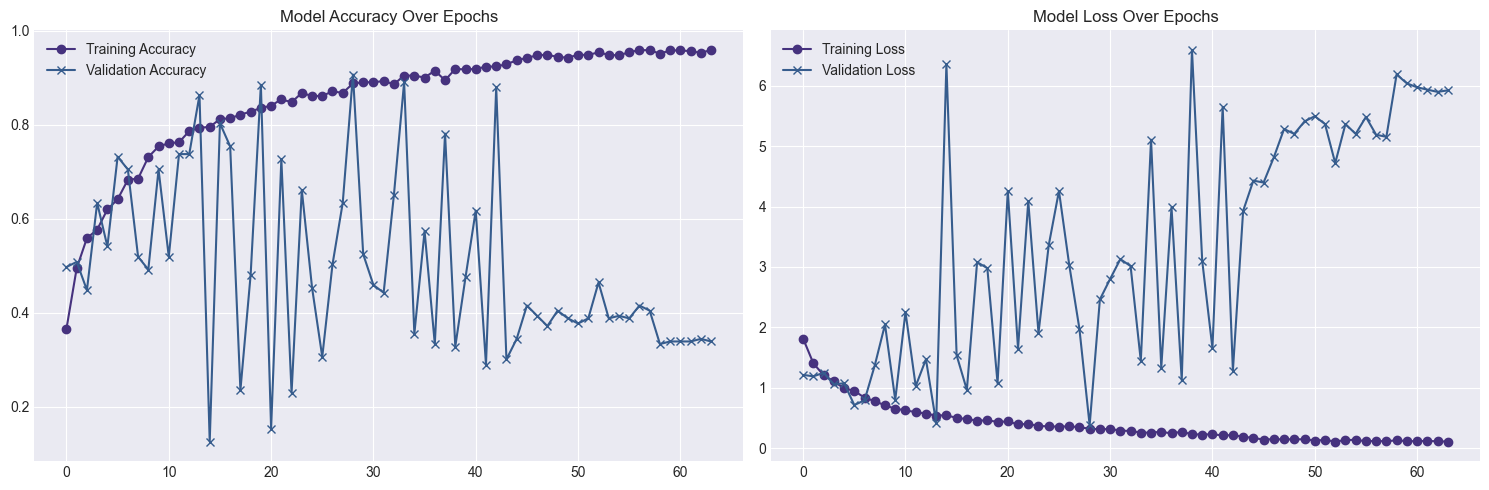

In [ ]:


# ✅ FIX: reshape for CNN
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Evaluate the model
score = model.evaluate(X_test_cnn, y_test, batch_size=60, verbose=0)

accuracy = score[1]
loss = score[0]

print(f'\033[1;92mAccuracy: {accuracy:.2%}\033[0m')
time.sleep(1)

print(f"\033[1;92mLoss: {loss:.4f}\033[0m\n")
time.sleep(1)

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='x')
axes[1].set_title('Model Loss Over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Plotting Confusion Matrix
The confusion matrix and classification report are generated to evaluate model predictions against true labels. The confusion matrix is then displayed with percentage annotations using a heatmap.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
                   precision    recall  f1-score   support

             COPD     0.9742    0.9497    0.9618       159
          Healthy     0.7500    0.8571    0.8000         7
             URTI     0.5000    0.5000    0.5000         4
        Pneumonia     0.3846    0.7143    0.5000         7
Bronchial_Disease     0.6667    0.3333    0.4444         6

         accuracy                         0.9071       183
        macro avg     0.6551    0.6709    0.6412       183
     weighted avg     0.9226    0.9071    0.9109       183



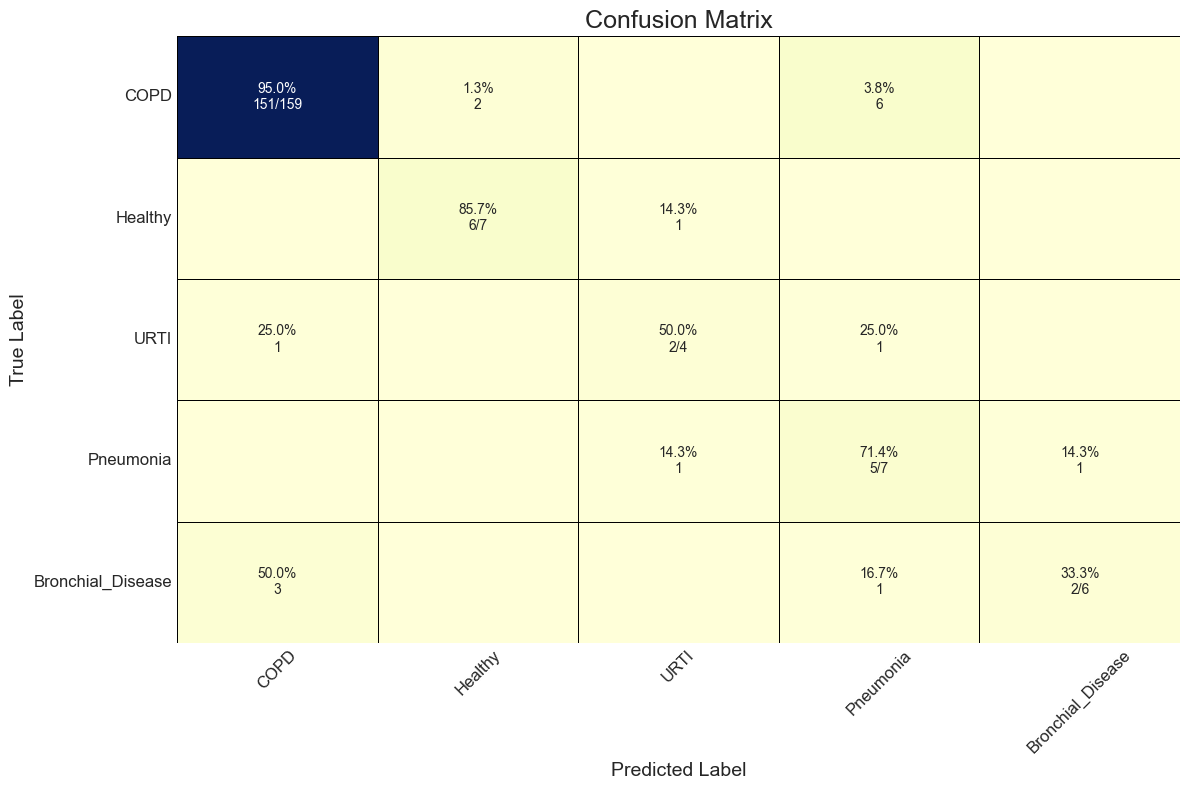

In [ ]:

import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Updated class index for the current 5-class dataset
matrix_index = ["COPD", "Healthy", "URTI", "Pneumonia", "Bronchial_Disease"]

# Make predictions
preds = model.predict(X_test)
class_preds = np.argmax(preds, axis=1)  # Predicted classes
y_test_class = np.argmax(y_test, axis=1)  # True classes

# Compute confusion matrix
cm = confusion_matrix(y_test_class, class_preds)

# Print classification report
print(classification_report(y_test_class, class_preds, target_names=matrix_index, digits=4))

# Calculate percentage values for the confusion matrix
cm_sum = np.sum(cm, axis=1, keepdims=True)
cm_perc = cm / cm_sum.astype(float) * 100

# Create annotations for the confusion matrix
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        c = cm[i, j]
        p = cm_perc[i, j]
        if i == j:
            annot[i, j] = f'{p:.1f}%\n{c}/{cm_sum[i][0]}'
        elif c == 0:
            annot[i, j] = ''
        else:
            annot[i, j] = f'{p:.1f}%\n{c}'

# Display the confusion matrix
df_cm = pd.DataFrame(cm, index=matrix_index, columns=matrix_index)
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'

plt.figure(figsize=(12, 8))
heatmap = sn.heatmap(
    df_cm, annot=annot, fmt='', cmap='YlGnBu', cbar=False,
    linewidths=.5, linecolor='black'
)
heatmap.set_title('Confusion Matrix', fontsize=18)
heatmap.set_xlabel('Predicted Label', fontsize=14)
heatmap.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0, fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()

### Plotting ROC & AUC
ROC curves are computed and plotted for each class to evaluate the model's performance. The curves and their respective AUC values are displayed in a plot with distinct colors for each class.

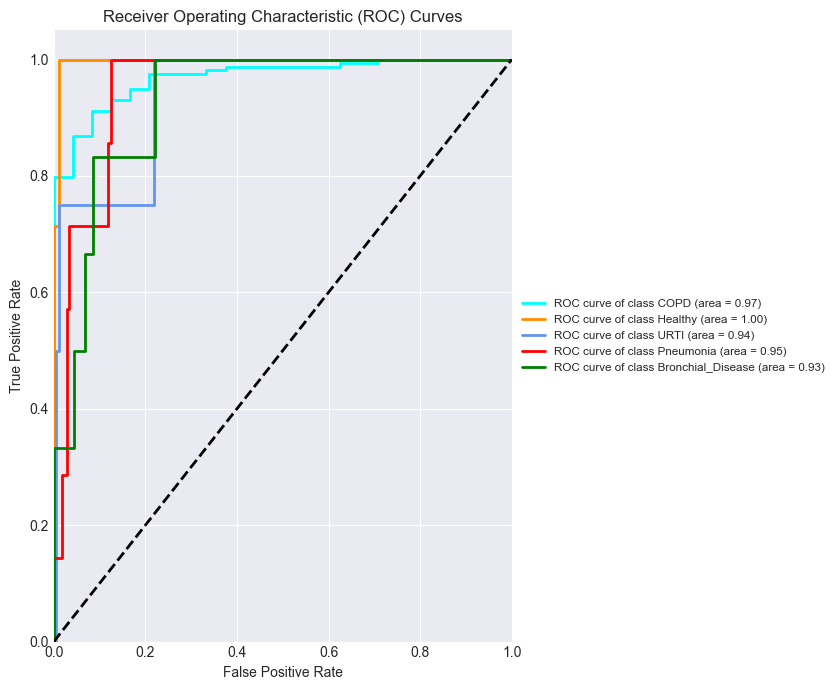

In [ ]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 7))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'blue'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {matrix_index[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')  # Adjust legend position
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room on the right for the legend
plt.show()


### Plotting Precision-Recall Curves
Precision-recall curves are computed and plotted for each class to further evaluate model performance. The curves are displayed with distinct colors and labels for each class, including a legend and grid for clarity.

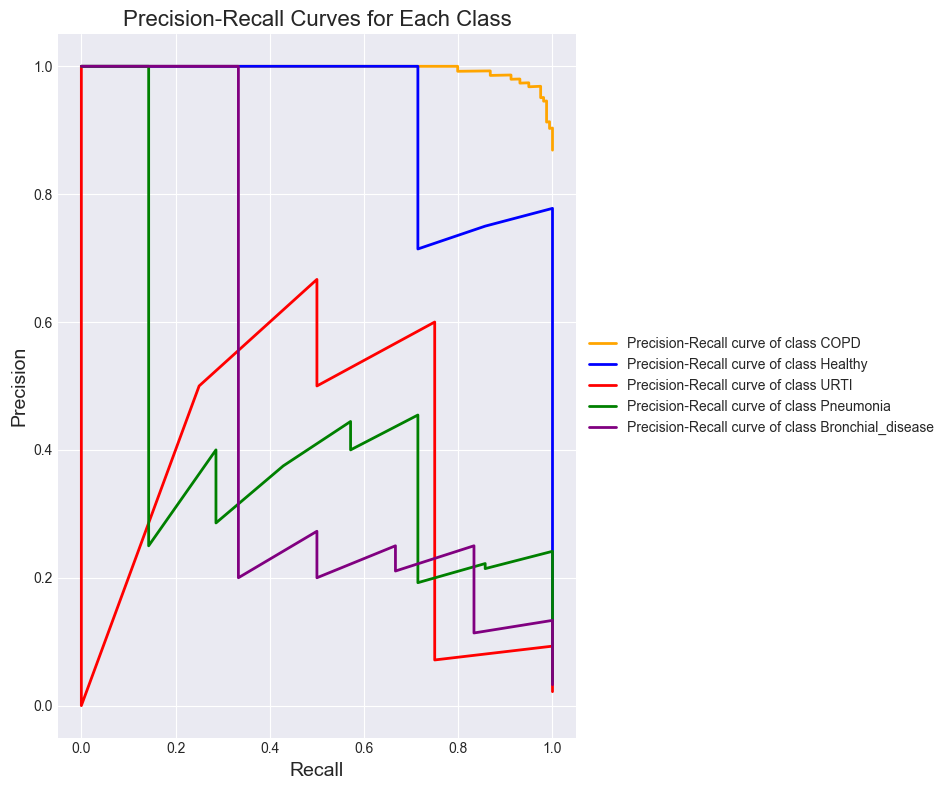

In [ ]:
n_classes = 5
colors = ['orange', 'blue', 'red', 'green', 'purple']
matrix_index = ['COPD', 'Healthy', 'URTI', 'Pneumonia', 'Bronchial_disease']

# Compute precision-recall curve for each class
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], preds[:, i])

# Plot Precision-Recall curves
plt.figure(figsize=(12, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'Precision-Recall curve of class {matrix_index[i]}')

# Adding grid, titles, and labels
plt.grid(True)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curves for Each Class', fontsize=16)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='medium')  # Adjust legend position

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 0.8, 1])

plt.show()

## Evaluation - ANN

### Plotting Accuracy & Loss

Accuracy: 91%
Loss: 0.2781



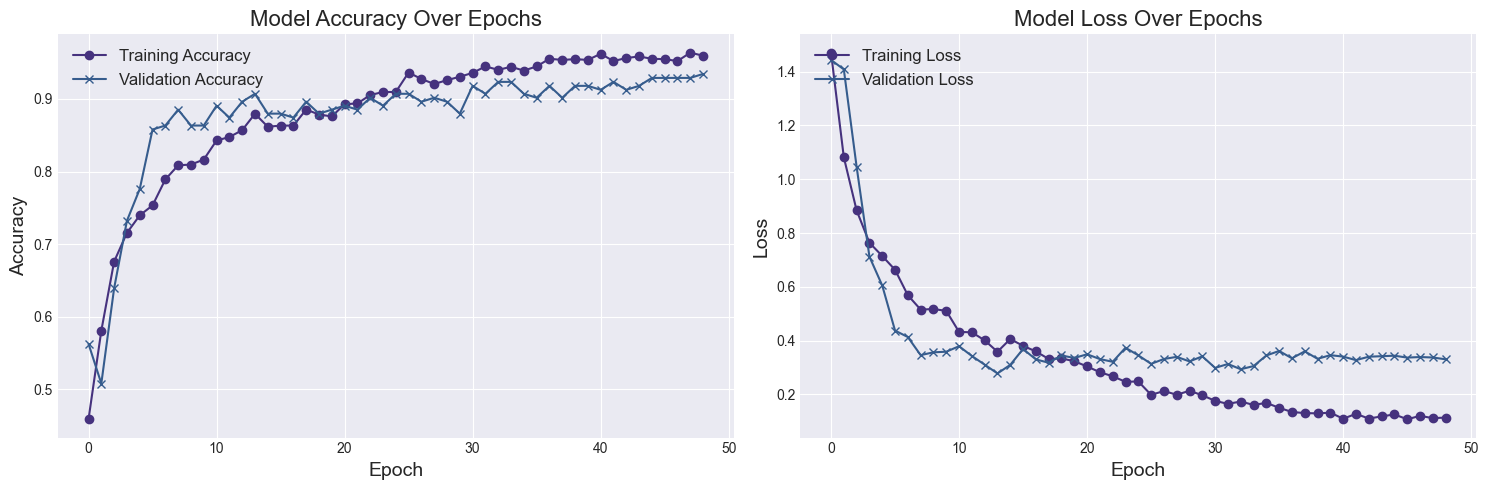

In [ ]:
# Evaluate the ANN model
score = ann_model.evaluate(X_test, y_test, batch_size=200, verbose=0)

# Print accuracy and loss in green
accuracy2 = score[1]
loss2 = score[0]

print(f'\033[1;92mAccuracy: {accuracy2:.0%}\033[0m')

time.sleep(1)

print(f"\033[1;92mLoss: {loss2:.4f}\033[0m\n")

time.sleep(1)

# Plot learning curves for accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot training & validation accuracy values
axes[0].plot(training_history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(training_history.history['val_accuracy'], label='Validation Accuracy', marker='x')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=16)
axes[0].set_ylabel('Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].legend(loc='upper left', fontsize=12)
axes[0].grid(True)

# Plot training & validation loss values
axes[1].plot(training_history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(training_history.history['val_loss'], label='Validation Loss', marker='x')
axes[1].set_title('Model Loss Over Epochs', fontsize=16)
axes[1].set_ylabel('Loss', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].legend(loc='upper left', fontsize=12)
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Plotting Confusion Matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
                   precision    recall  f1-score   support

             COPD       0.99      0.95      0.97       159
          Healthy       0.75      0.43      0.55         7
             URTI       0.50      0.75      0.60         4
        Pneumonia       0.31      0.57      0.40         7
Bronchial_Disease       0.71      0.83      0.77         6

         accuracy                           0.91       183
        macro avg       0.65      0.71      0.66       183
     weighted avg       0.93      0.91      0.92       183



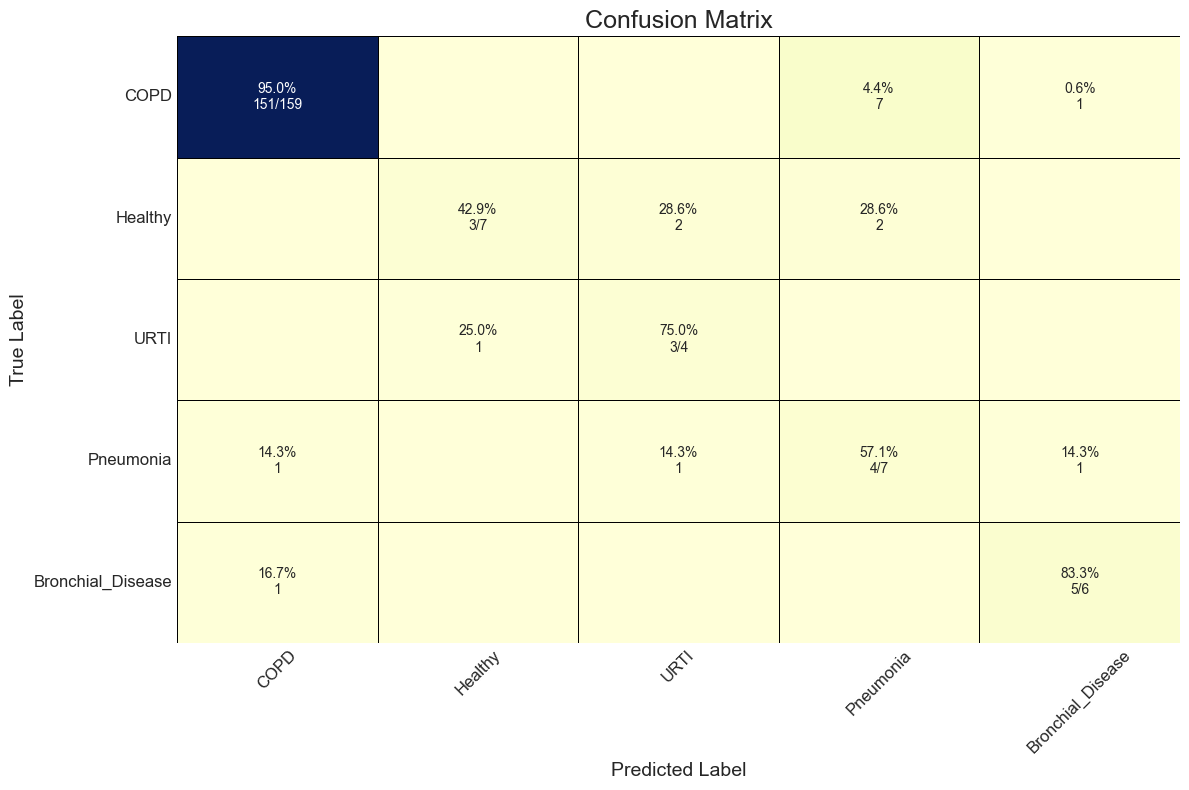

In [ ]:
# Define matrix index
matrix_index = ["COPD", "Healthy", "URTI", "Pneumonia", "Bronchial_Disease"]

# Make predictions
preds = ann_model.predict(X_test)
class_preds = np.argmax(preds, axis=1)  # Predicted classes
y_test_class = np.argmax(y_test, axis=1)  # True classes

# Compute confusion matrix
cm = confusion_matrix(y_test_class, class_preds)
print(classification_report(y_test_class, class_preds, target_names=matrix_index))

# Calculate percentage values for the confusion matrix
cm_sum = np.sum(cm, axis=1, keepdims=True)
cm_perc = cm / cm_sum.astype(float) * 100

# Create annotations for the confusion matrix
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        c = cm[i, j]
        p = cm_perc[i, j]
        if i == j:
            annot[i, j] = f'{p:.1f}%\n{c}/{cm_sum[i][0]}'
        elif c == 0:
            annot[i, j] = ''
        else:
            annot[i, j] = f'{p:.1f}%\n{c}'

# Display the confusion matrix
df_cm = pd.DataFrame(cm, index=matrix_index, columns=matrix_index)
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'

plt.figure(figsize=(12, 8))
heatmap = sn.heatmap(df_cm, annot=annot, fmt='', cmap='YlGnBu', cbar=False, linewidths=.5, linecolor='black')
heatmap.set_title('Confusion Matrix', fontsize=18)
heatmap.set_xlabel('Predicted Label', fontsize=14)
heatmap.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0, fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()
plt.show()


### Plotting ROC & AUC

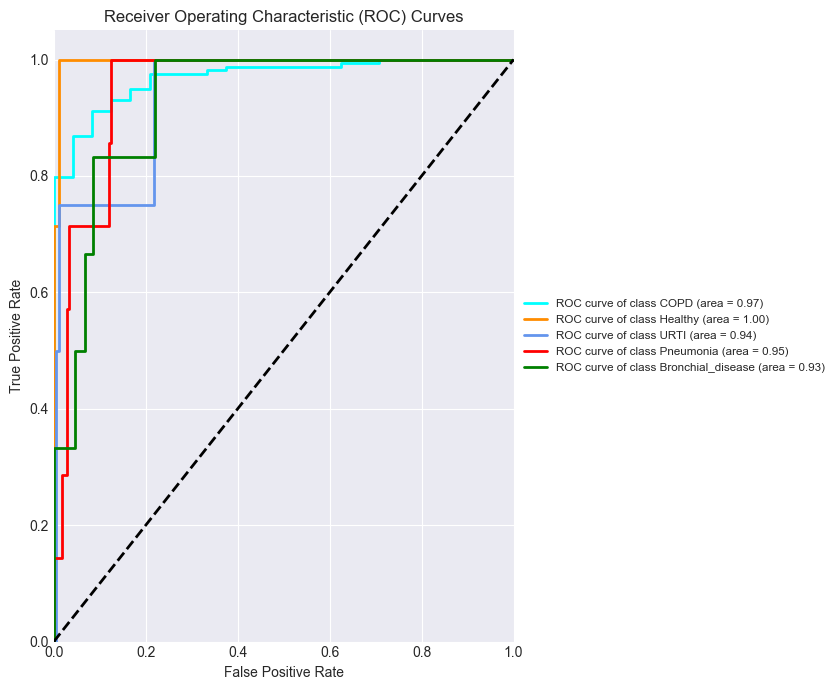

In [ ]:
# Compute ROC curve and ROC area for each class
false_positive_rate = dict()
true_positive_rate = dict()
roc_auc_score = dict()
num_classes = y_test.shape[1]

for i in range(num_classes):
    false_positive_rate[i], true_positive_rate[i], _ = roc_curve(y_test[:, i], preds[:, i])
    roc_auc_score[i] = auc(false_positive_rate[i], true_positive_rate[i])

# Plot ROC curves
plt.figure(figsize=(10, 7))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'blue'])
for i, color in zip(range(num_classes), colors):
    plt.plot(false_positive_rate[i], true_positive_rate[i], color=color, lw=2,
             label=f'ROC curve of class {matrix_index[i]} (area = {roc_auc_score[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')  # Adjust legend position
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room on the right for the legend
plt.show()


### Plotting Precision-Recall Curves

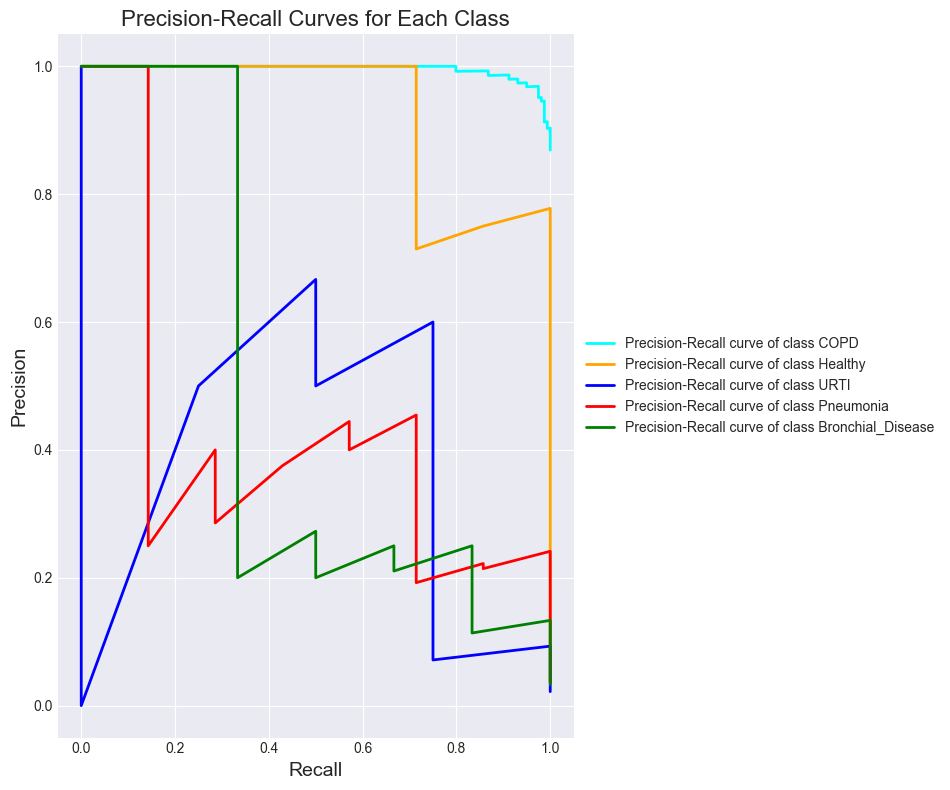

In [ ]:
# Define the number of classes, class names, and colors
num_classes = 5
class_names = ['COPD', 'Healthy', 'URTI', 'Pneumonia', 'Bronchial_Disease']
colors = ['cyan', 'orange', 'blue', 'red', 'green', 'purple']

# Compute precision-recall curve for each class
precision_dict = {}
recall_dict = {}
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], preds[:, i])

# Plot Precision-Recall curves
plt.figure(figsize=(12, 8))
for i, color in zip(range(num_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'Precision-Recall curve of class {class_names[i]}')

# Adding grid, titles, and labels
plt.grid(True)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curves for Each Class', fontsize=16)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='medium')  # Adjust legend position

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 0.8, 1])

plt.show()

## Comparison of the two Models

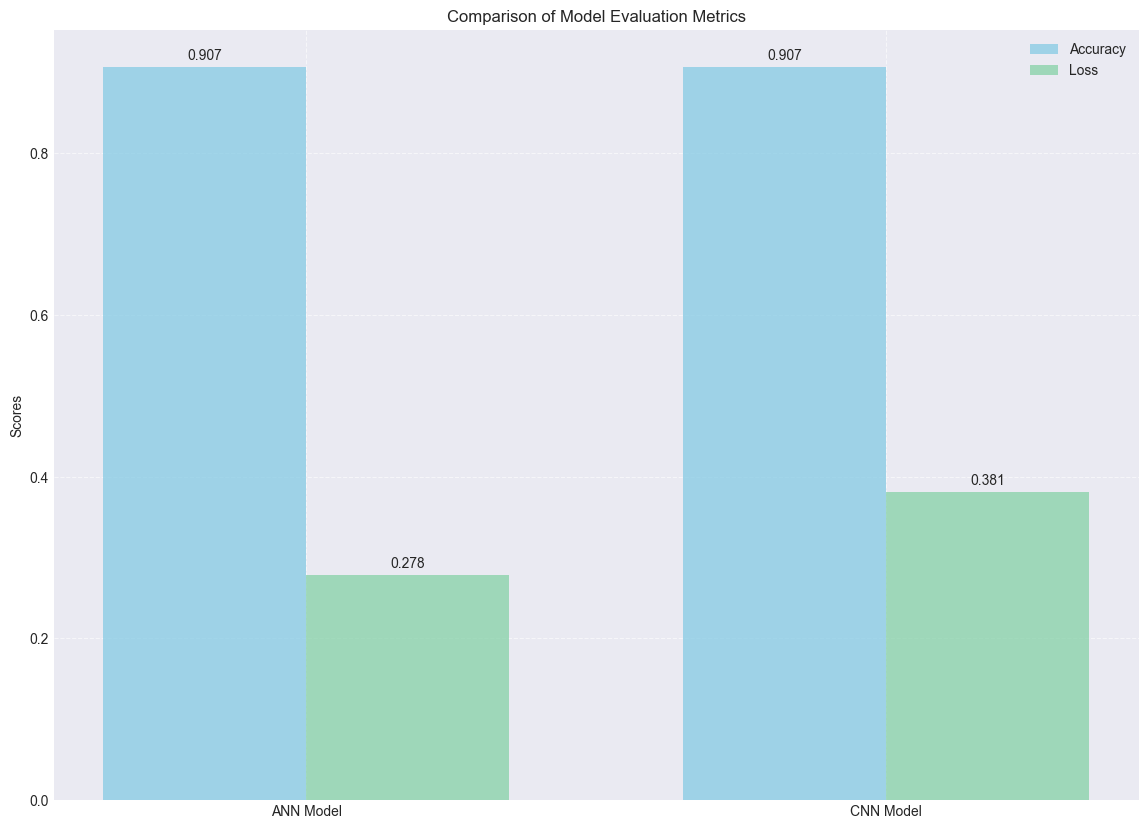

--------------------------------------------------
SUCCESS: ANN Model saved as the BEST MODEL to: CNN & ANN/best_model_ann.h5
ANN Accuracy (90.71%) is higher than CNN.
--------------------------------------------------


In [ ]:
# Data for Model 1 (ANN Model)
ann_accuracy = accuracy2  # Using accuracy obtained from ANN model evaluation
ann_loss = loss2  # Using loss obtained from ANN model evaluation

# Data for Model 2 (CNN Model)
cnn_accuracy = accuracy  # Using accuracy obtained from model evaluation
cnn_loss = loss  # Using loss obtained from model evaluation

# Define slightly darker pastel colors
pastel_blue = '#7EC8E3'
pastel_green = '#7ECFA2'

# Plotting
labels = ['ANN Model', 'CNN Model']
accuracies = [ann_accuracy, cnn_accuracy]
losses = [ann_loss, cnn_loss]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 10))

# Plot accuracy bars
ax.bar(x, accuracies, width, label='Accuracy', color=pastel_blue, alpha=0.7)

# Plot loss bars
ax.bar([i + width for i in x], losses, width, label='Loss', color=pastel_green, alpha=0.7)

# Attach a text label above each bar displaying its height
for i, (accuracy, loss) in enumerate(zip(accuracies, losses)):
    ax.annotate(f'{accuracy:.3f}', xy=(i, accuracy), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
    ax.annotate(f'{loss:.3f}', xy=(i + width, loss), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

ax.set_ylabel('Scores')
ax.set_title('Comparison of Model Evaluation Metrics')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()


if ann_accuracy >= cnn_accuracy:
    # We choose to save the ANN model
    MODEL_SAVE_PATH = 'CNN & ANN/best_model_ann.h5'
    
    # [*** CRITICAL ACTION ***] Save the ANN model with the deployment name
    ann_model.save(MODEL_SAVE_PATH)
    
    print("-" * 50)
    print(f"SUCCESS: ANN Model saved as the BEST MODEL to: {MODEL_SAVE_PATH}")
    print(f"ANN Accuracy ({ann_accuracy*100:.2f}%) is higher than CNN.")
    print("-" * 50)
else:
     MODEL_SAVE_PATH = 'CNN & ANN/best_model_cnn.h5'
    
    # [*** CRITICAL ACTION ***] Save the ANN model with the deployment name
     model.save(MODEL_SAVE_PATH)
    
     print("-" * 50)
     print(f"SUCCESS: CNN Model saved as the BEST MODEL to: {MODEL_SAVE_PATH}")
     print(f"CNN Accuracy ({cnn_accuracy*100:.2f}%) is higher than ANN.")
     print("-" * 50)
    # (If the CNN model were better, you would save it here instead)
     print("CNN model was better. ANN model was not saved as 'best_model.h5'.")

# --- 4. Final Verification and Cleanup ---
# Now, your final file for the Flask app is ready.

## Summary and Conclusion

This notebook performed an in-depth analysis and modelling of respiratory sound data, which included the following key steps:
1. `Data Loading and Preprocessing`:
   - Audio files and diagnosis data were loaded and preprocessed.
   - Relevant audio features were extracted for model training.

2. `Data Visualization`:
   - Various plots were generated to visualize class distributions, audio file durations, and model performance.

3. `Model Building and Evaluation`:
   - A Convolutional Neural Network (CNN) was built and trained to classify respiratory diseases.
   - An Artificial Neural Network (ANN) was built and trained to classify respiratory diseases.
   - The models were evaluated using accuracy, loss, confusion matrix, ROC curves, and precision-recall curves.

4. `Results`:
   - The models showed promising results in classifying different respiratory conditions.
   - Visualizations provided insights into the model's performance and helped identify areas for improvement.